# 딥러닝 - 신경망 - 다항분류

In [4]:
from hossam import *

from pandas import DataFrame
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np

from datetime import datetime as dt
from keras_tuner import Hyperband

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, RMSprop
from tensorflow.keras.losses import mse
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import AUC, F1Score

from tqdm.keras import TqdmCallback

# 로지스틱 성능평가 함수
from sklearn.metrics import confusion_matrix

# 다항 분류의 종속변수 처리를 위한 기능
from tensorflow.keras.utils import to_categorical

## 1. 데이터 가져오기


In [5]:
origin = load_data('iris')
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print(origin.info())
origin.head()

1936년 영국의 통계학자 로널드 피셔(Ronald A. Fisher)가 소개한 3가지 품종(setosa, versicolor, virginica)의 붓꽃(Iris)에 대한 꽃받침과 꽃잎의 길이와 너비 측정값으로 구성된 유명한 머신러닝 및 데이터 분석용 데이터셋.(출처: Kaggle)

field         description
------------  -------------
Sepal.Length  꽃밭침 길이
Sepal.Width   꽃밭침 너비
Petal.Length  꽃잎 길이
Petal.Width   꽃잎 너비
Species       품종

데이터셋 크기: (150, 5)
열 개수: 5
행 개수: 150
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB
None


,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa


## 2. 탐색적 데이터 분석
### 1. 데이터 품질 검사

In [6]:
desc = origin.describe().T

# 숫자형 칼럼 이름만 추출
num_cols = origin.select_dtypes(include=np.number).columns

# 왜도 확인 및 로그 변환 필요성
for column in num_cols:
    skewness = origin[column].skew()
    if abs(skewness) < 0.5:
        strength = 'week'
        log_transform = 'not needed'
    elif abs(skewness) < 1:
        strength = 'normal'
        log_transform = 'recommended'
    else:
        strength = 'strong'
        log_transform = 'needed'
    
    desc.loc[column, 'skewness'] = skewness
    desc.loc[column, 'skewness_strength'] = strength
    desc.loc[column, 'log_transform'] = log_transform
desc

,count,mean,std,min,25%,50%,75%,max,skewness,skewness_strength,log_transform
Sepal.Length,150.000,5.843,0.828,4.300,5.100,5.800,6.400,7.900,0.315,week,not needed
Sepal.Width,150.000,3.057,0.436,2.000,2.800,3.000,3.300,4.400,0.319,week,not needed
Petal.Length,150.000,3.758,1.765,1.000,1.600,4.350,5.100,6.900,-0.275,week,not needed
Petal.Width,150.000,1.199,0.762,0.100,0.300,1.300,1.800,2.500,-0.103,week,not needed


## 3. 데이터 전처리
### 1. 종속변수 라벨링

In [7]:
origin['Species'].value_counts()


Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [9]:
df = origin.copy()
df['Species'] = df['Species'].map({'setosa': 0, 'versicolor': 1, 'virginica': 2})
df['Species'].value_counts()

Species
0    50
1    50
2    50
Name: count, dtype: int64

### 2. 훈련, 검증 데이터 분리

In [10]:
yname = 'Species'
x = df.drop(columns = [yname])
y = df[yname]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state = 52)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((112, 4), (38, 4), (112,), (38,))

In [11]:
# 원래는 다중 공선성 제거도 고려해봐야 한다
_, cols = x_train.shape
cols

4

### 3. 데이터 스케일링

In [12]:
df = x_train.copy()
scaler = StandardScaler()
scaler.fit(df)

x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

### 4. 종속변수에 대한 to_categorical() 함수 적용
- Tensorflow에서만 필요한 처리
- one-hot-encoding 처리 수행

In [13]:
y_train_cate = to_categorical(y_train)
y_test_cate = to_categorical(y_test)
y_train_cate[:5]

array([[0., 0., 1.],
       [0., 1., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 1., 0.]])

In [14]:
classes = y_train_cate.shape[1]
classes

3

## 4. 훈련 모델 적합
### 1. 하이퍼파라미터 튜닝 함수

In [17]:
def tf_build(hp) -> Sequential:
    model = Sequential()

    # 입력층 정의
    model.add(Input(shape = (cols,)))

    # 은닉층 --> 유닛 수를 하이퍼파라미터로 조정
    model.add(
        Dense(
            units = hp.Choice('units', values = [4, 8, 16, 32, 64]),
            activation = 'relu'
        )
    )

    # 출력층: 클래스 개수만큼의 뉴런
    # 로지스틱 모델이기 때문에 활성화 함수는 softmax
    model.add(Dense(classes, activation = 'softmax')) # 3개의 클래스에 대한 출력

    # 모델 학습 설정 (컴파일 단계)
    model.compile(
        optimizer = 'adam',
        # 다항분류이므로 손실률을 categorical_crossentropy로 설정
        loss = 'categorical_crossentropy',
        # accuracy: 정확도, AUC, F1Score
        metrics = ['accuracy', AUC(name = 'auc'), F1Score(name = 'f1_score', average = 'macro')]
    )

    return model

### 2. 튜너 객체 생성

In [18]:
tuner = Hyperband(
    hypermodel = tf_build,       # 하이퍼파라미터를 튜닝하기 위한 모델 생성 함수
    objective = 'accuracy',       # 최적화 기준값
    max_epochs = 10,
    factor = 3,
    seed = 52,
    directory = 'tensor_tuning',
    project_name = 'tf_hyperband_%s' % dt.now().strftime('%Y%m%d%H%M%S')
)

tuner

### 3. 하이퍼파라미터 튜닝 수행

In [21]:
%%time

tuner.search(
    x_train_scaled, y_train_cate, epochs = 10, batch_size = 32, validation_data = (x_test_scaled, y_test_cate)
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters()

if not best_hps:
    raise ValueError('No best hyperparameters found')

print(f'''best hyperparameters: {best_hps[0].values}''')

Trial 5 Complete [00h 00m 03s]
accuracy: 0.5535714030265808

Best accuracy So Far: 0.5892857313156128
Total elapsed time: 00h 02m 44s
best hyperparameters: {'units': 16, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}
CPU times: user 8.85 s, sys: 455 ms, total: 9.3 s
Wall time: 9.97 s


### 4. 최종 모형 도출

In [22]:
model = tuner.hypermodel.build(best_hps[0])

result = model.fit(
    x_train_scaled,                                # 학습 데이터 입력
    y_train_cate,                                # 학습 데이터의 타겟값 (정답)
    epochs = 500,                           # 전체 학습 데이터셋을 500회 반복하여 학습
    validation_data = (x_test_scaled, y_test_cate),     # 검증 데이터 설정
    verbose = 0,                            # 학습 과정 출력 생략
    callbacks = [
        TqdmCallback(verbose = 1),          # 학습 진행 상황을 tqdm 형태로 보여주는 콜백 추가
        # 조기 종료 콜백
        # 너무 일찍 조기종료하면 모델이 충분히 학습되지 않고 에러율이 높게 나올 수 있음
        EarlyStopping(monitor = 'val_loss', patience = 5, min_delta = 0.001),

        # 학습률 감소 콜백: 검증 손실(val_loss)이 10회 연속 개선되지 않으면 학습률을 0.5배로 감소
        ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 10, min_lr = 0, verbose = 1)
    ]
)
result

0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

## 5. 성능평가
### 1. 성능평가 지표

In [23]:
# Train 성능평가
# metrics = ['accuracy']에 의해 evaluate()가 반환하는 리스트 순서는 [loss, accuracy]
train_eval = model.evaluate(x_train_scaled, y_train_cate, verbose = 0, return_dict = True)
test_eval = model.evaluate(x_test_scaled, y_test_cate, verbose = 0, return_dict = True)

# DataFrame 생성
final_results = DataFrame([train_eval, test_eval])
final_results.insert(0, 'Dataset', ['Train', 'Test'])

# Gap 계산
for metric in ['loss', 'accuracy', 'auc', 'f1_score']:
    final_results[f'{metric}_gap'] = None
    final_results.loc[1, f'{metric}_gap'] = (
        final_results.loc[1, metric] - final_results.loc[0, metric]
    )

final_results

,Dataset,accuracy,auc,f1_score,loss,loss_gap,accuracy_gap,auc_gap,f1_score_gap
0,Train,0.973,0.999,0.972,0.099,None,None,None,None
1,Test,0.974,0.998,0.977,0.136,0.037,0.000,-0.002,0.005


### 2. 학습 과정 확인

In [24]:
history_df = DataFrame(data = result.history)
history_df['epoch'] = history_df.index + 1

history_df.head()

,accuracy,auc,f1_score,loss,val_accuracy,val_auc,val_f1_score,val_loss,learning_rate,epoch
0,0.259,0.345,0.240,1.437,0.421,0.623,0.341,1.127,0.001,1
1,0.259,0.370,0.239,1.396,0.447,0.640,0.349,1.096,0.001,2
2,0.268,0.394,0.245,1.358,0.447,0.652,0.349,1.068,0.001,3
3,0.277,0.419,0.250,1.321,0.474,0.666,0.377,1.040,0.001,4
4,0.286,0.446,0.257,1.286,0.500,0.679,0.392,1.015,0.001,5


### 3. Loss, RMSE 학습곡선

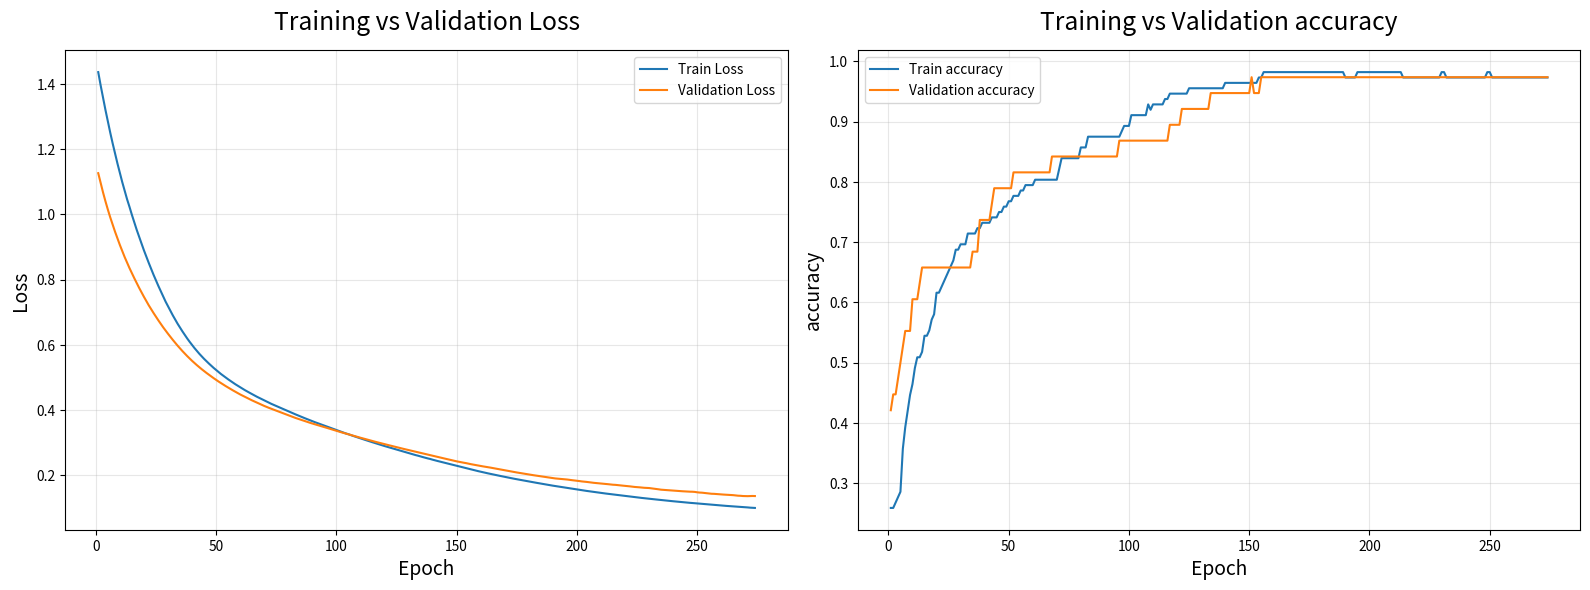

In [25]:
figsize = (1600/ 100, 600 / 100)
fig, ax = plt.subplots(1, 2, figsize = figsize, dpi = 100)
fig.subplots_adjust(wspace = 0.2, hspace = 0.2)

# 훈련 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'loss', ax = ax[0], label = 'Train Loss'
           )

# 검증 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'val_loss', ax = ax[0], label = 'Validation Loss'
           )

# 그래프 꾸미기
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].set_title('Training vs Validation Loss')  

ax[0].grid(True, alpha = 0.3)

# 훈련 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'accuracy', ax = ax[1], label = 'Train accuracy'
           )

# 검증 데이터 손실률
sb.lineplot(data = history_df, x= 'epoch', y = 'val_accuracy', ax = ax[1], label = 'Validation accuracy'
           )

# 그래프 꾸미기
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('accuracy')
ax[1].set_title('Training vs Validation accuracy')  

ax[1].grid(True, alpha = 0.3)

# 출력
plt.tight_layout()
plt.show()
plt.close()

## 6. 예측 결과 활용
### 1. 예측치 구하기

In [34]:
pred = model.predict(x_test_scaled, verbose = 0)
pred[:5]

array([[9.9336886e-01, 4.9705897e-03, 1.6604579e-03],
       [9.9900502e-01, 7.1594591e-04, 2.7891286e-04],
       [5.8084919e-05, 7.0685497e-03, 9.9287331e-01],
       [8.3524625e-05, 1.9081969e-02, 9.8083442e-01],
       [6.3967476e-05, 5.5219404e-02, 9.4471651e-01]], dtype=float32)

### 2. 결과 데이터 셋 구성


In [35]:
pred_classes = np.argmax(pred, axis = 1)
pred_classes[:5]

array([0, 0, 2, 2, 2])

In [36]:
kdf = DataFrame({
    '실제값': y_test,
    '분류값': pred_classes
})

kdf.head()

,실제값,분류값
43,0,0
37,0,0
143,2,2
145,2,2
107,2,2


### 3. 관측치와 예측치 비교 시각화

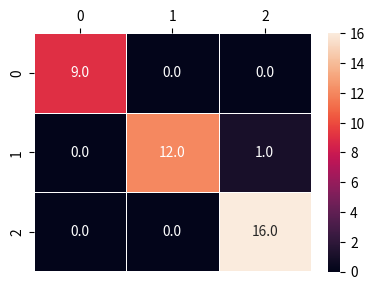

In [37]:
cm = confusion_matrix(
    kdf['실제값'],
    kdf['분류값']
)
figsize = (400 / 100, 300 / 100)
fig, ax = plt.subplots(1, 1, figsize = figsize, dpi = 100)
sb.heatmap(data = cm, annot = True, fmt = '0.1f', linewidth = 0.5)
ax.set_xlabel('')
ax.set_ylabel('')
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()
plt.close()